In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [30]:
df = pd.read_csv("Performance.csv")

print(df.shape)
print(df.columns)
print(df.dtypes)

df.describe()

(93364, 14)
Index(['aggregate_date', 'place_name', 'region', 'place_type', 'carrier_name',
       'aggregation_period', 'technology_type', 'sample_count',
       'mean_download_kbps', 'mean_upload_kbps', 'mean_latency_ms',
       'median_download_kbps', 'median_upload_kbps', 'median_latency_ms'],
      dtype='str')
aggregate_date            str
place_name                str
region                    str
place_type                str
carrier_name              str
aggregation_period        str
technology_type           str
sample_count            int64
mean_download_kbps      int64
mean_upload_kbps        int64
mean_latency_ms         int64
median_download_kbps    int64
median_upload_kbps      int64
median_latency_ms       int64
dtype: object


,sample_count,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps,median_upload_kbps,median_latency_ms
count,93364.000000,9.336400e+04,93364.000000,93364.000000,9.336400e+04,93364.000000,93364.000000
mean,37.772964,1.040574e+05,17845.626708,41.204436,9.460949e+04,16153.527527,39.462673
std,474.379735,1.187946e+05,14981.087044,26.174070,1.163168e+05,14914.169222,25.007443
min,1.000000,6.000000e+00,1.000000,1.000000,6.000000e+00,1.000000,1.000000
25%,1.000000,2.406300e+04,7091.750000,30.000000,1.946900e+04,5975.000000,29.000000
50%,2.000000,6.209300e+04,14411.000000,37.000000,5.280300e+04,11969.500000,36.000000
75%,5.000000,1.408845e+05,24390.000000,46.000000,1.222460e+05,21773.000000,44.000000
max,32028.000000,1.135477e+06,157354.000000,687.000000,1.135477e+06,157354.000000,687.000000


Sample count threshold: 5.0


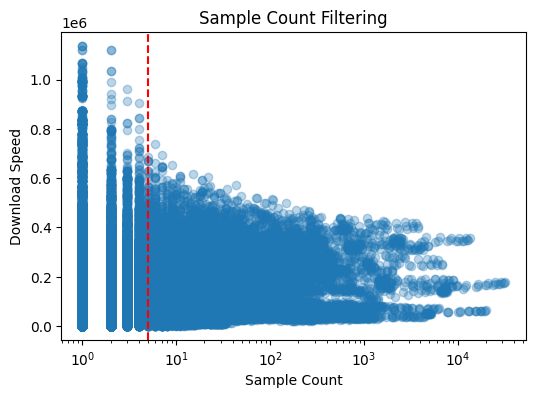

In [31]:
# Choose threshold based on distribution
threshold = df['sample_count'].quantile(0.75)
print("Sample count threshold:", threshold)

# Visual check
plt.figure(figsize=(6,4))
plt.scatter(df['sample_count'], df['mean_download_kbps'], alpha=0.3)
plt.xscale('log')
plt.axvline(x=threshold, color='red', linestyle='--')
plt.xlabel("Sample Count")
plt.ylabel("Download Speed")
plt.title("Sample Count Filtering")
plt.show()

In [32]:
df_filtered = df[
    (df['sample_count'] >= threshold) &
    (df['place_type'] == 'locality') &
    (df['aggregation_period'] == 'Day')
].copy()

df_filtered['aggregate_date'] = pd.to_datetime(df_filtered['aggregate_date'])

print("Filtered rows:", len(df_filtered))

Filtered rows: 8086


In [33]:
df_clean = df_filtered.groupby(
    ['aggregate_date', 'region', 'carrier_name', 'technology_type']
).agg({
    'median_latency_ms': 'median',
    'median_download_kbps': 'median',
    'median_upload_kbps': 'median'
}).reset_index()

df_model = df_clean.copy()
df_model = df_model.sort_values('aggregate_date')

In [34]:
def mad_z(series):
    med = np.median(series)
    mad = np.median(np.abs(series - med))
    if mad == 0:
        return np.zeros(len(series))
    return 0.6745 * (series - med) / mad

# Apply per carrier + technology
df_model['latency_z'] = df_model.groupby(
    ['carrier_name', 'technology_type']
)['median_latency_ms'].transform(mad_z)

df_model['download_z'] = df_model.groupby(
    ['carrier_name', 'technology_type']
)['median_download_kbps'].transform(mad_z)

df_model['upload_z'] = df_model.groupby(
    ['carrier_name', 'technology_type']
)['median_upload_kbps'].transform(mad_z)

# Clean infinities / NaNs
df_model[['latency_z','download_z','upload_z']] = df_model[
    ['latency_z','download_z','upload_z']
].replace([np.inf, -np.inf], np.nan).fillna(0)

In [35]:
#df_model['anomaly'] = (
#    df_model['latency_z'].abs() > 3.5
#) | (
#    df_model['download_z'].abs() > 3.5
#) | (
#    df_model['upload_z'].abs() > 3.5

#)




df_model['latency_anomaly'] = df_model['latency_z'] > 3.5      # high latency = bad
df_model['download_anomaly'] = df_model['download_z'] < -3.5   # low download = bad
df_model['upload_anomaly'] = df_model['upload_z'] < -3.5       # low upload = bad

df_model['anomaly'] = (
    df_model['latency_anomaly'] |
    df_model['download_anomaly'] |
    df_model['upload_anomaly']
)

In [36]:

#def get_cause(row):
#    scores = {
#        'latency': abs(row['latency_z']),
#        'download': abs(row['download_z']),
#        'upload': abs(row['upload_z'])
#    }
#    return max(scores, key=scores.get)

def get_cause(row):
    issues = {}

    if row['latency_z'] > 3.5:
        issues['latency'] = row['latency_z']

    if row['download_z'] < -3.5:
        issues['download'] = abs(row['download_z'])

    if row['upload_z'] < -3.5:
        issues['upload'] = abs(row['upload_z'])

    return max(issues, key=issues.get) if issues else "normal"



anomalies_table = df_model[df_model['anomaly']].copy()
anomalies_table['main_cause'] = anomalies_table.apply(get_cause, axis=1)

# Severity score
anomalies_table['severity'] = anomalies_table[
    ['latency_z','download_z','upload_z']
].abs().max(axis=1)

anomalies_table = anomalies_table.sort_values('severity', ascending=False)

print("Total anomalies:", anomalies_table.shape[0])

Total anomalies: 27


In [37]:
print("Anomaly rate:", df_model['anomaly'].mean())

# Per technology
print(df_model.groupby('technology_type')['anomaly'].mean())

# Per region
print(df_model.groupby('region')['anomaly'].mean().sort_values(ascending=False).head())

Anomaly rate: 0.01396792550439731
technology_type
5G           0.010256
LTE          0.006359
Multi-RAT    0.023644
Name: anomaly, dtype: float64
region
Assiut     0.146067
Gharbia    0.089888
Sohag      0.027273
Minya      0.012346
Fayoum     0.006250
Name: anomaly, dtype: float64


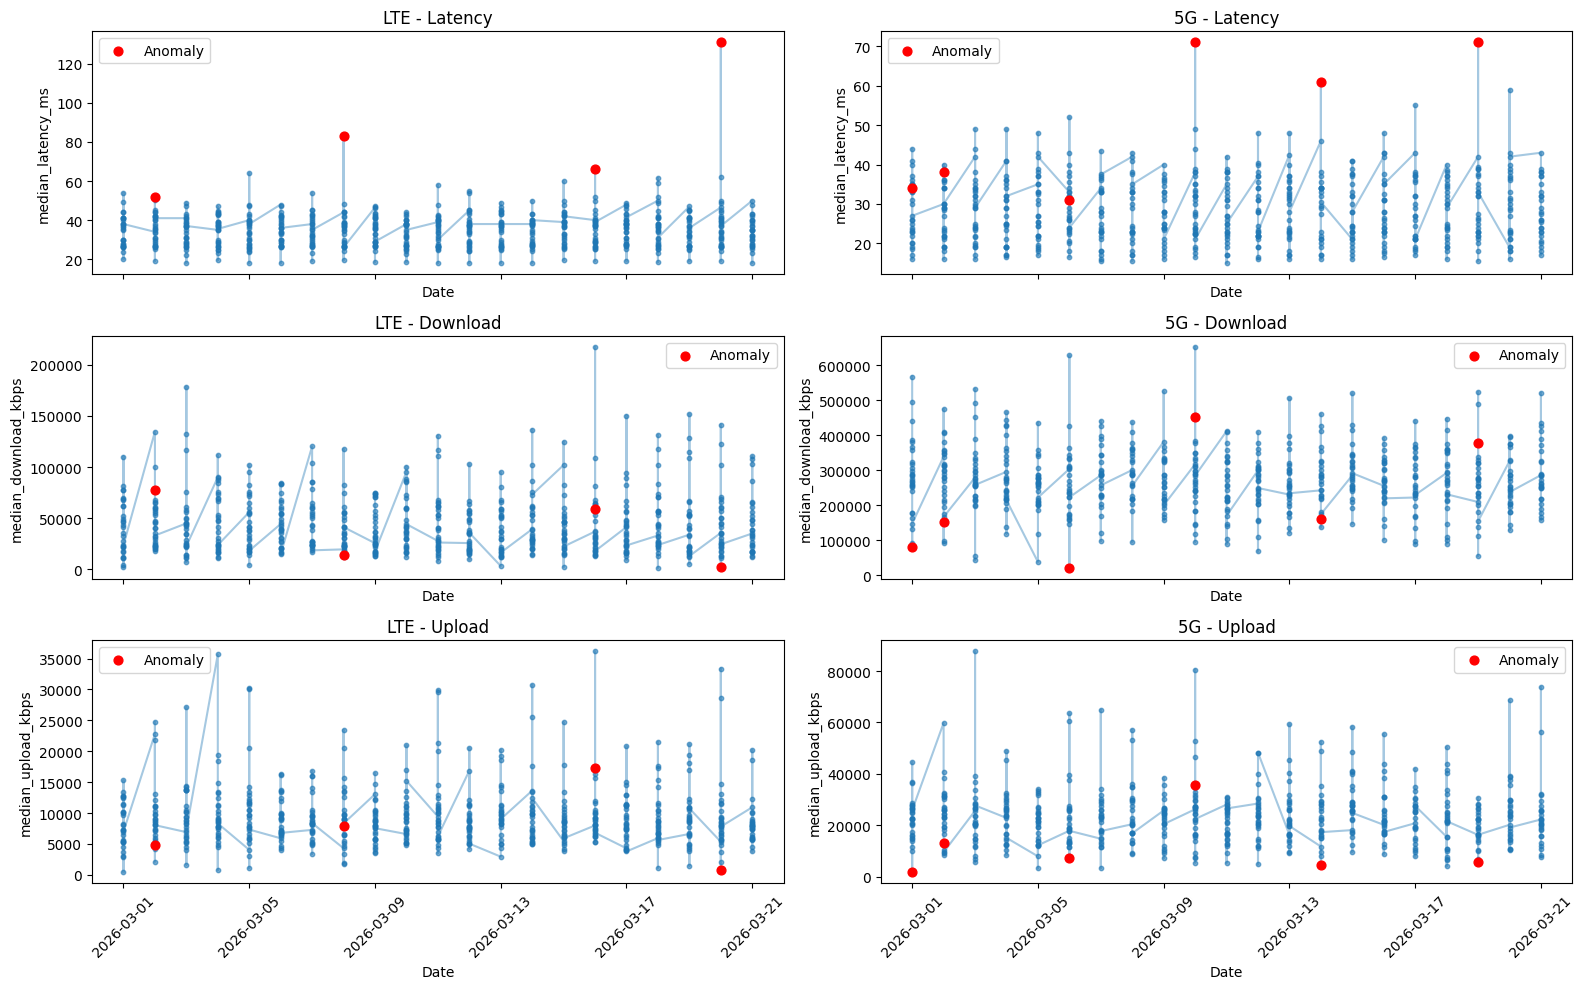

In [38]:
def plot_tech(ax, df, metric, title):
    ax.plot(df['aggregate_date'], df[metric], alpha=0.4)

    ax.scatter(df['aggregate_date'], df[metric],
               s=10, alpha=0.6)

    anomalies = df[df['anomaly']]

    ax.scatter(anomalies['aggregate_date'],
               anomalies[metric],
               color='red',
               s=40,
               label='Anomaly',
               zorder=5)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(metric)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)


fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)

# LTE
df_lte = df_model[df_model['technology_type'] == 'LTE']
plot_tech(axes[0, 0], df_lte, 'median_latency_ms', 'LTE - Latency')
plot_tech(axes[1, 0], df_lte, 'median_download_kbps', 'LTE - Download')
plot_tech(axes[2, 0], df_lte, 'median_upload_kbps', 'LTE - Upload')

# 5G
df_5g = df_model[df_model['technology_type'] == '5G']
plot_tech(axes[0, 1], df_5g, 'median_latency_ms', '5G - Latency')
plot_tech(axes[1, 1], df_5g, 'median_download_kbps', '5G - Download')
plot_tech(axes[2, 1], df_5g, 'median_upload_kbps', '5G - Upload')

plt.tight_layout()
plt.show()

In [39]:
def plot_region_tech(df, tech, region, metric):
    subset = df[
        (df['technology_type'] == tech) &
        (df['region'] == region)
    ]

    if subset.empty:
        return

    plt.figure(figsize=(10, 4))

    # Plot per carrier
    for carrier in subset['carrier_name'].unique():
        carrier_data = subset[subset['carrier_name'] == carrier]

        plt.scatter(carrier_data['aggregate_date'],
                    carrier_data[metric],
                    s=15, alpha=0.6, label=carrier)

    # Highlight anomalies
    anomalies = subset[subset['anomaly']]
    plt.scatter(anomalies['aggregate_date'],
                anomalies[metric],
                color='red',
                s=50,
                label='Anomaly',
                zorder=5)

    plt.title(f"{tech} - {region} - {metric}")
    plt.xlabel("Date")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [40]:
def plot_region_tech(df, tech, region, metric):
    subset = df[
        (df['technology_type'] == tech) &
        (df['region'] == region)
    ].copy()

    if subset.empty:
        return

    # 🔴 IMPORTANT: sort before plotting lines
    subset = subset.sort_values('aggregate_date')

    plt.figure(figsize=(10, 4))

    # Plot per carrier (line + scatter)
    for carrier in subset['carrier_name'].unique():
        carrier_data = subset[subset['carrier_name'] == carrier].sort_values('aggregate_date')

        # Line (connect points)
        plt.plot(carrier_data['aggregate_date'],
                 carrier_data[metric],
                 alpha=0.6)

        # Scatter (points)
        plt.scatter(carrier_data['aggregate_date'],
                    carrier_data[metric],
                    s=15, alpha=0.7, label=carrier)

    # Highlight anomalies
    anomalies = subset[subset['anomaly'] == True]

    plt.scatter(anomalies['aggregate_date'],
                anomalies[metric],
                color='red',
                s=60,
                label='Anomaly',
                zorder=5)

    plt.title(f"{tech} - {region} - {metric}")
    plt.xlabel("Date")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.legend()

    plt.tight_layout()
    plt.show()

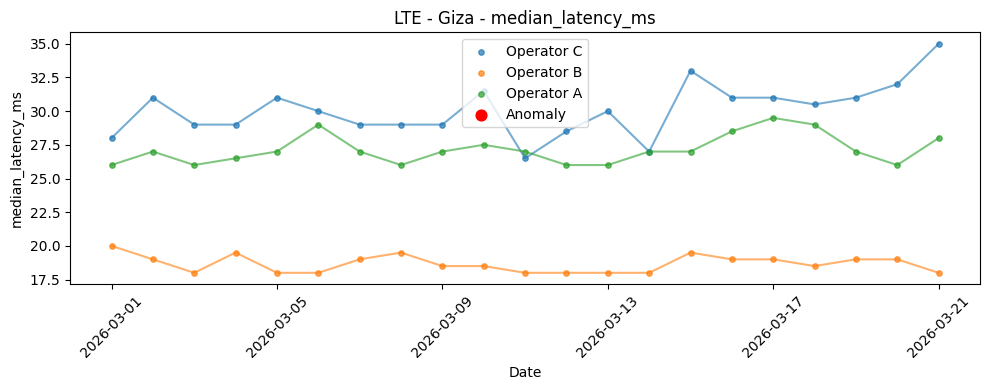

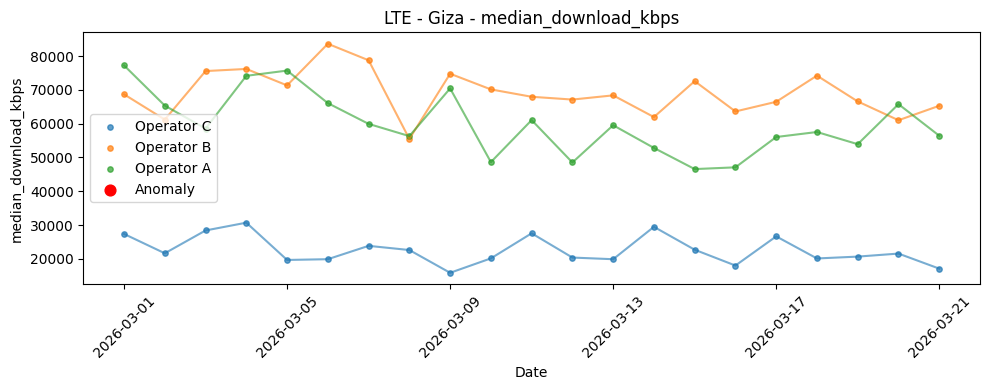

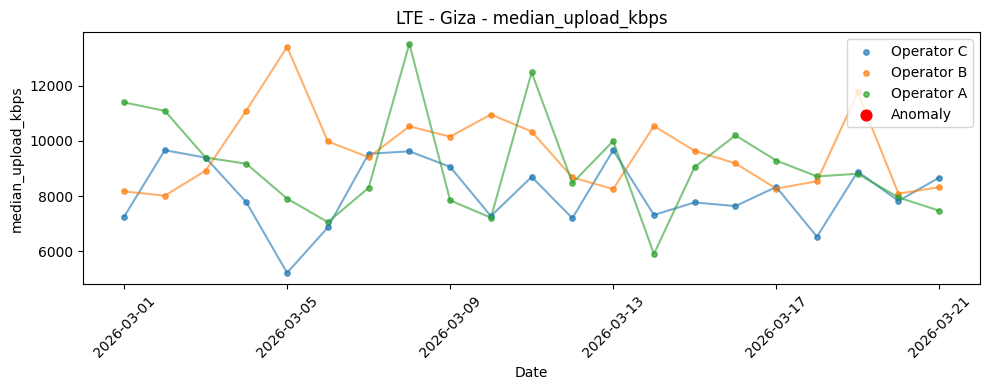

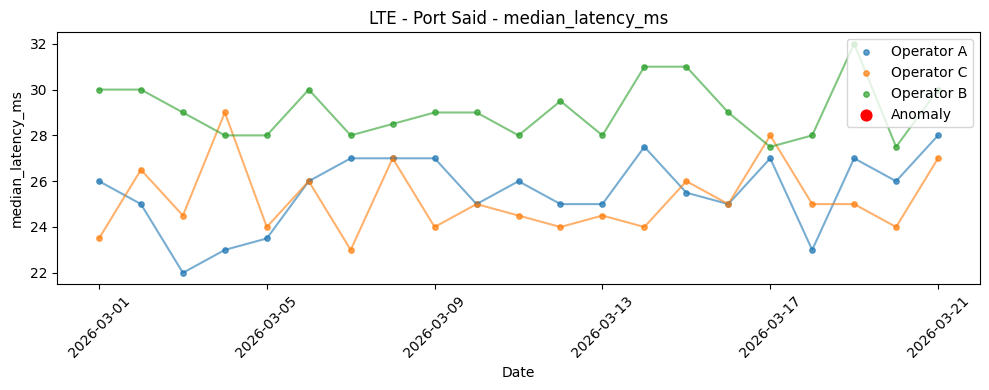

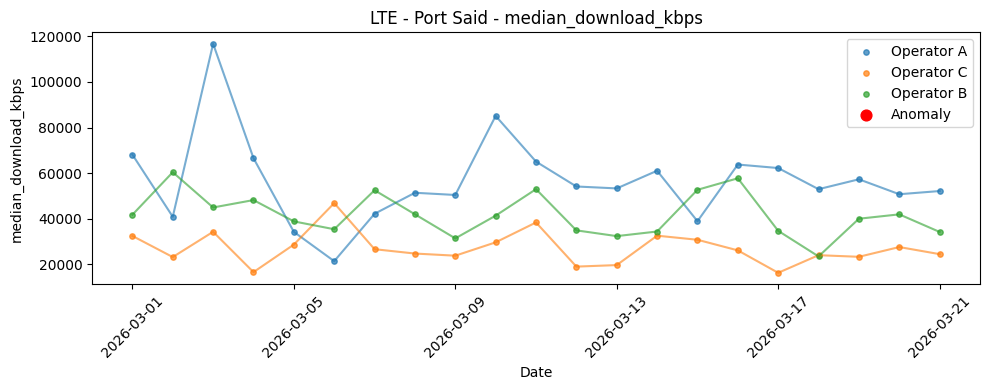

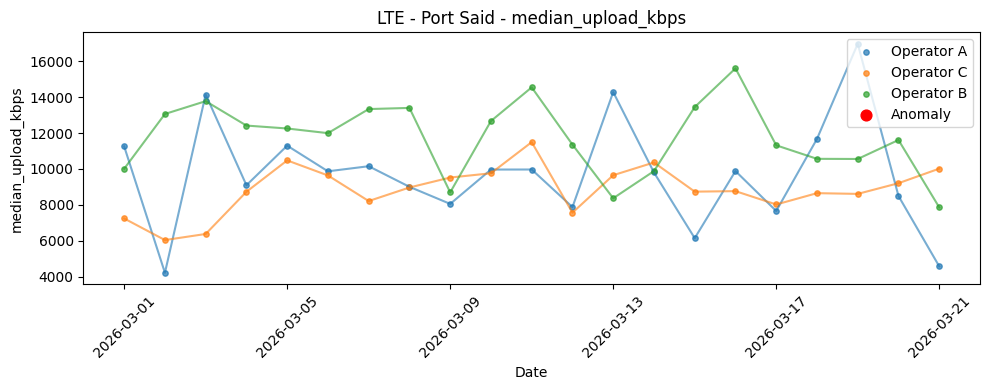

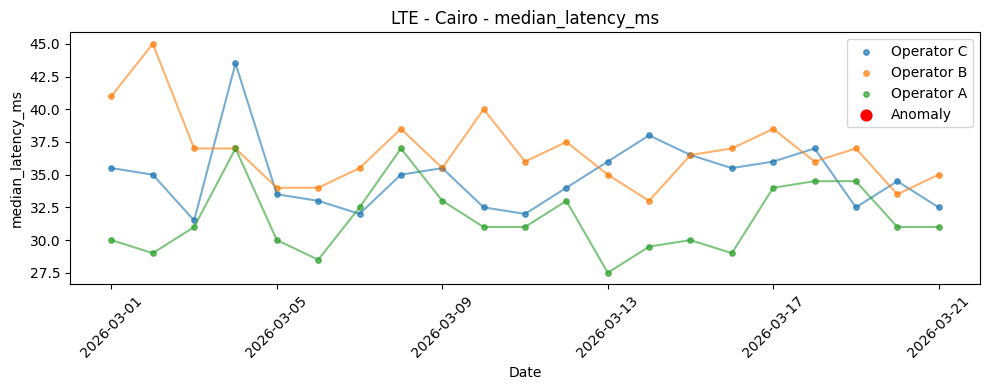

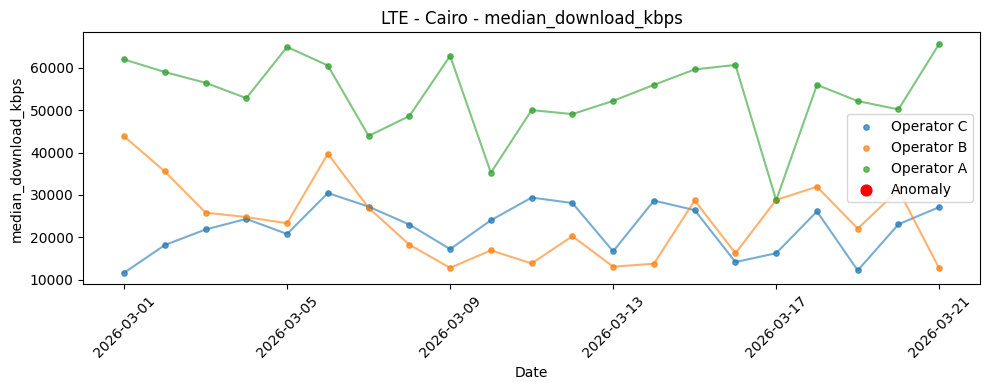

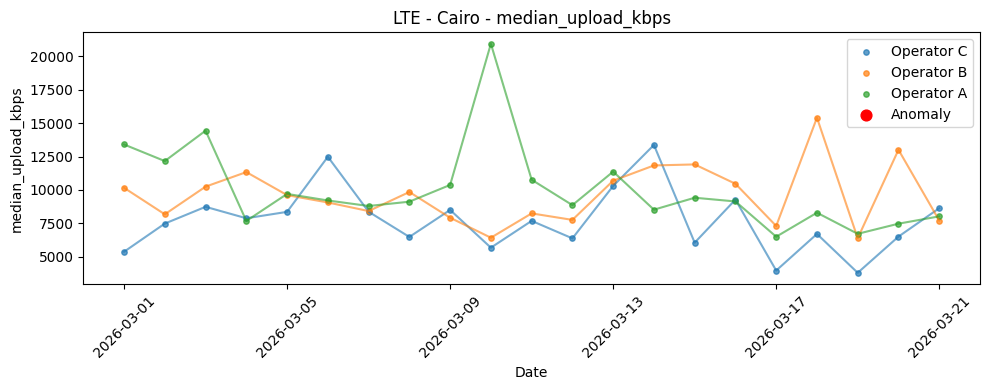

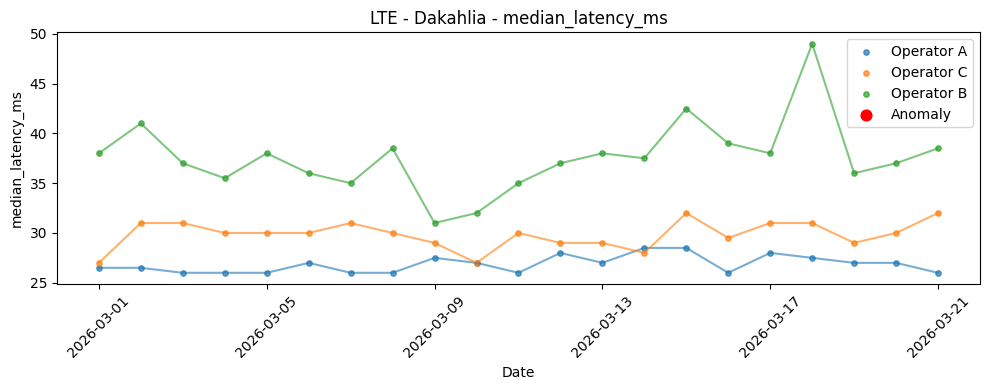

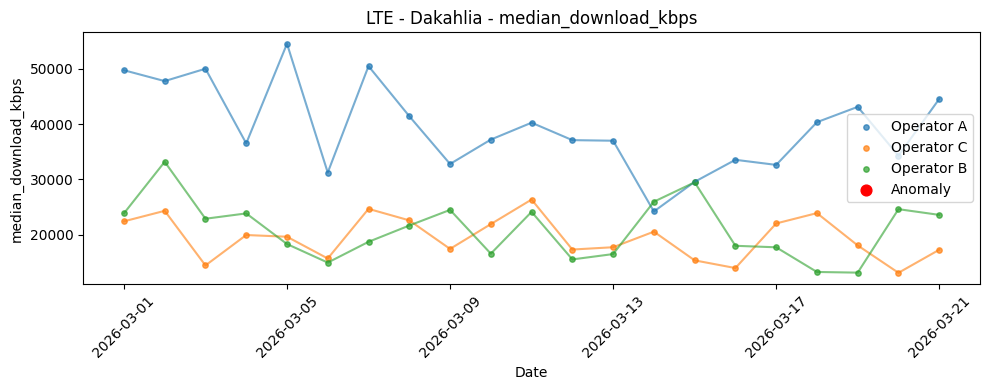

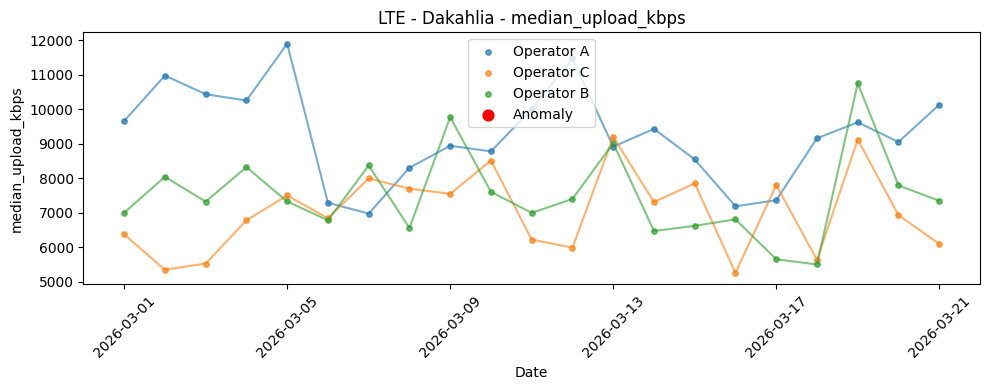

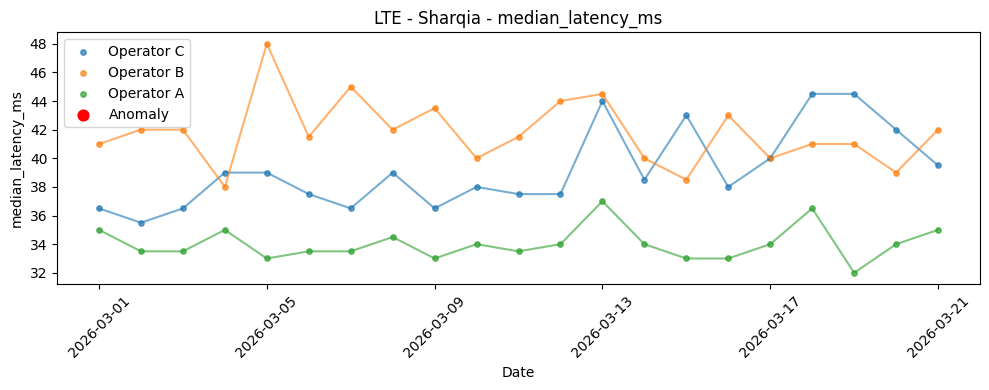

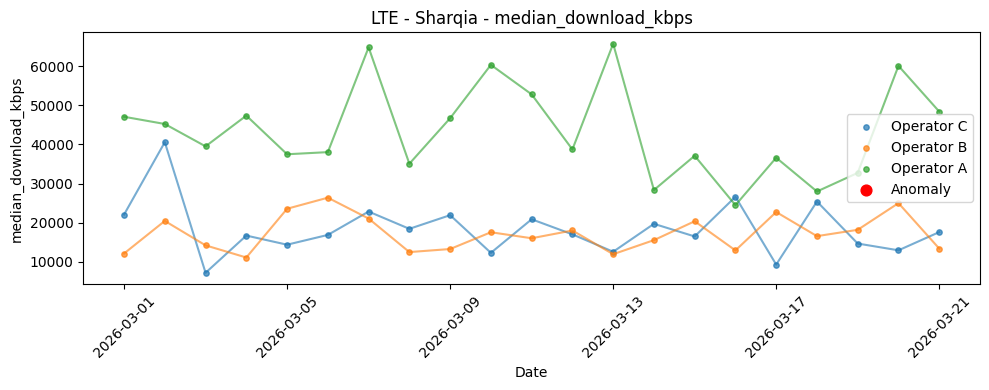

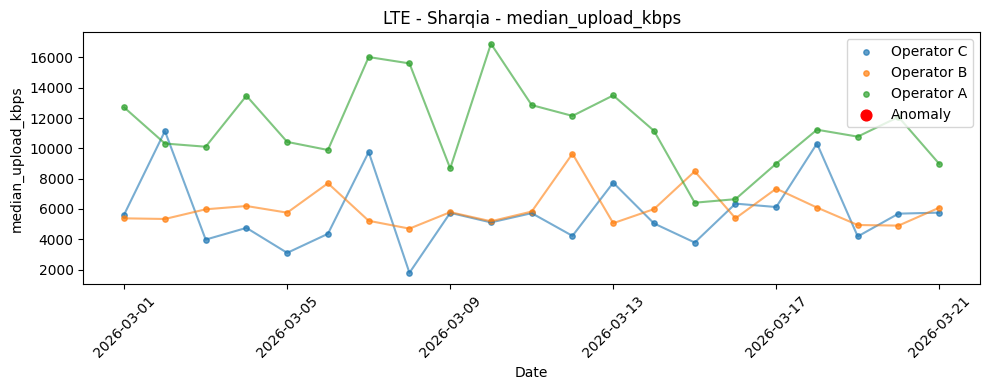

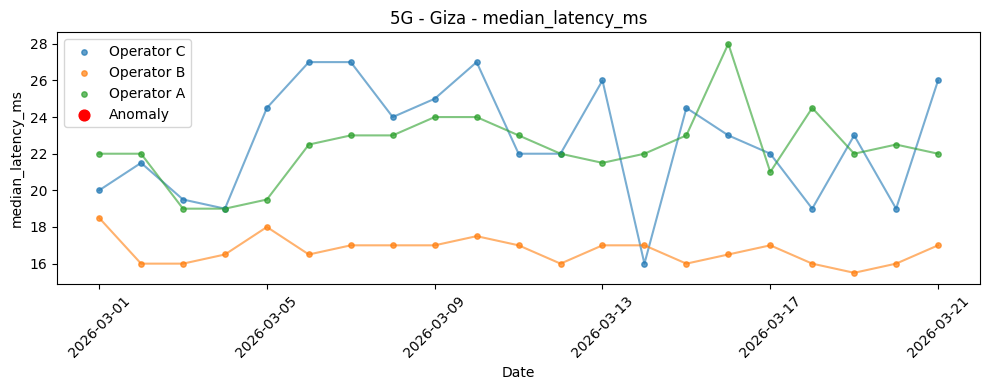

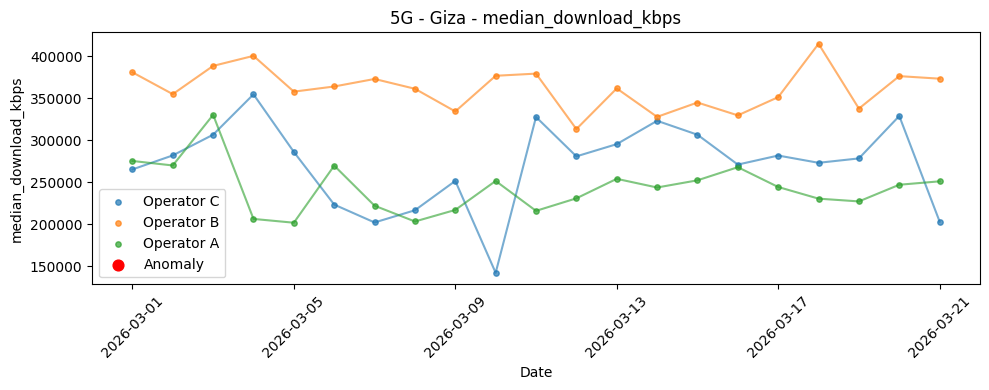

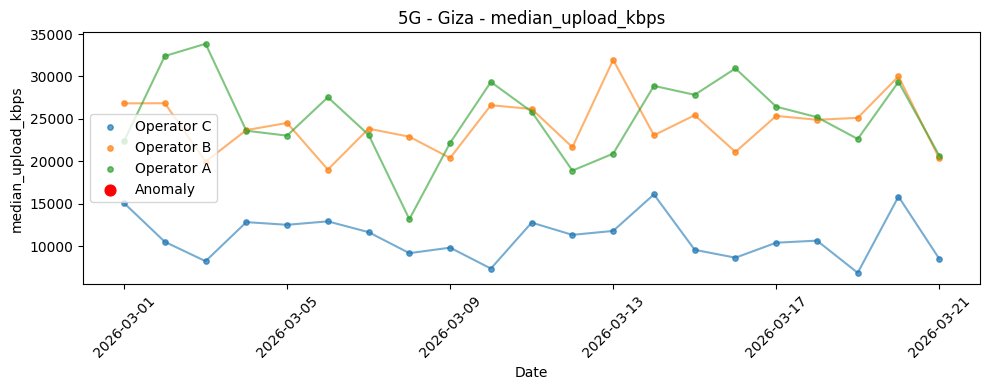

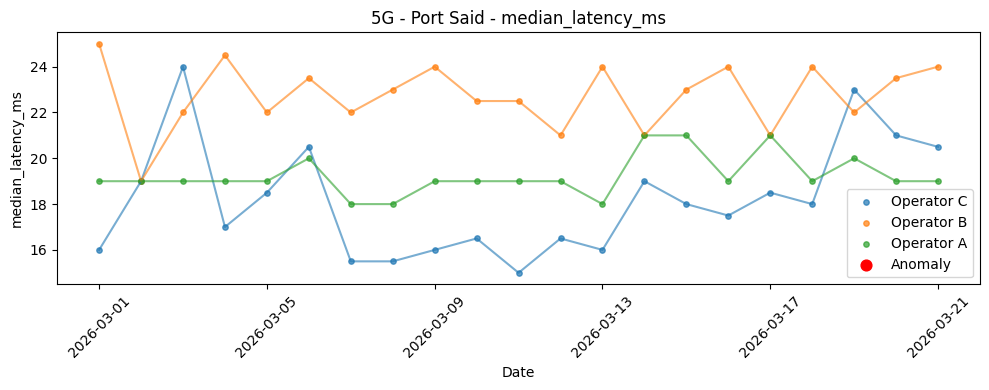

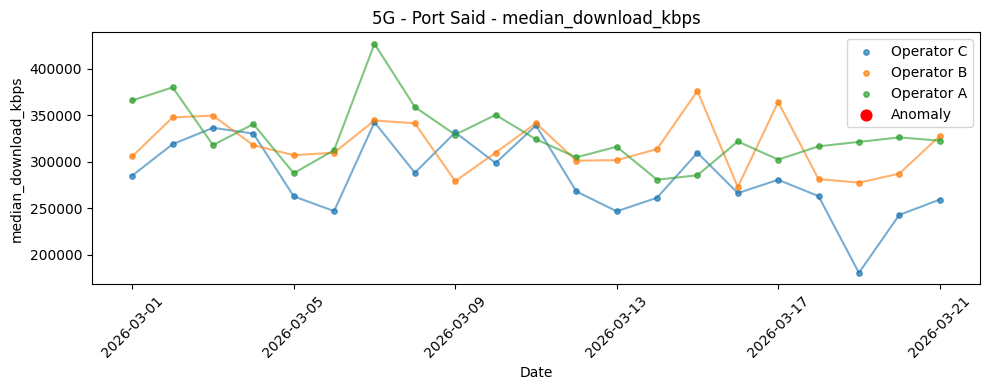

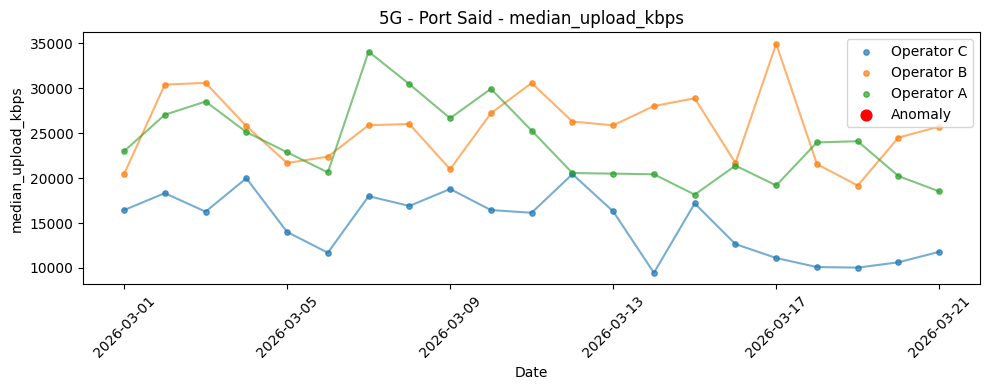

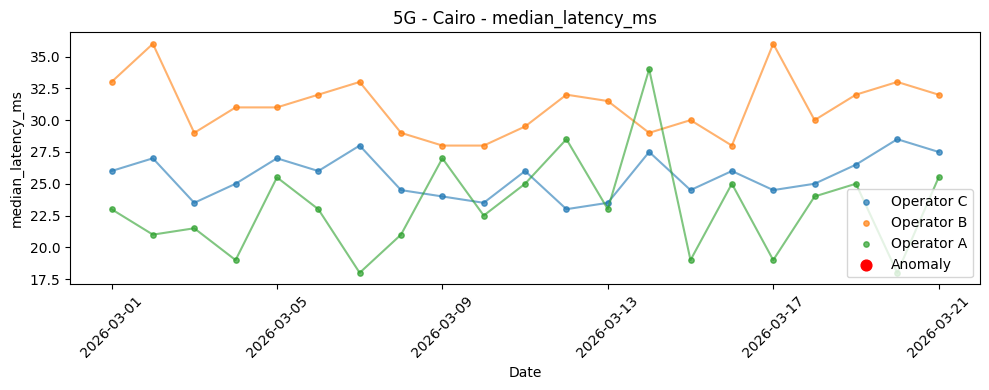

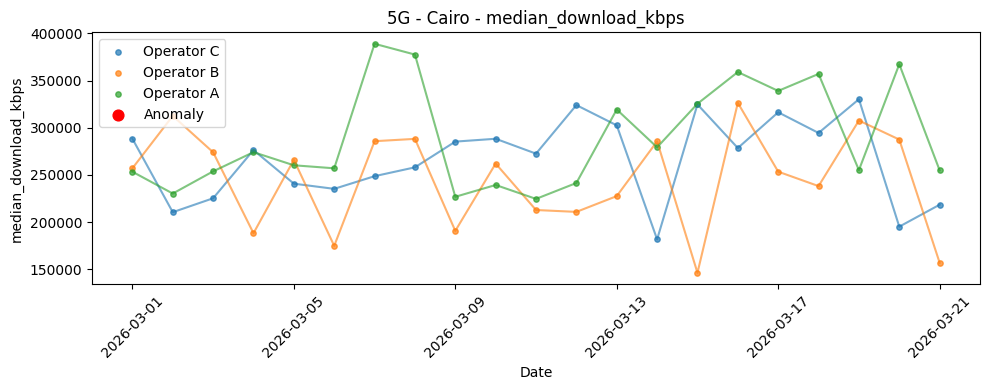

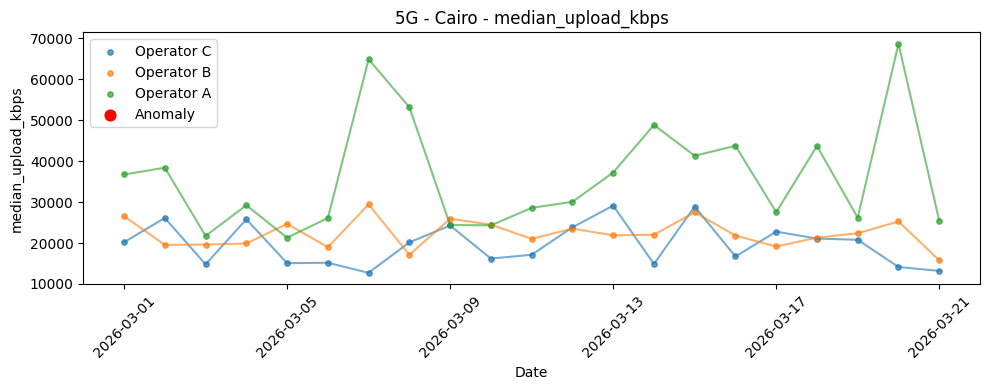

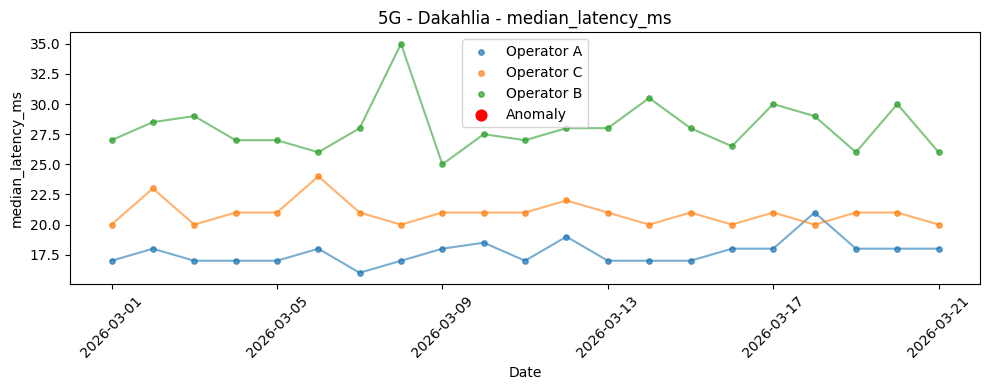

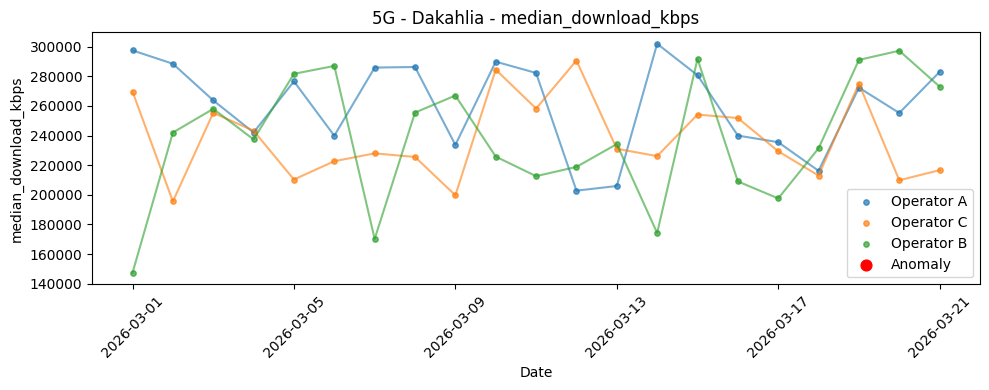

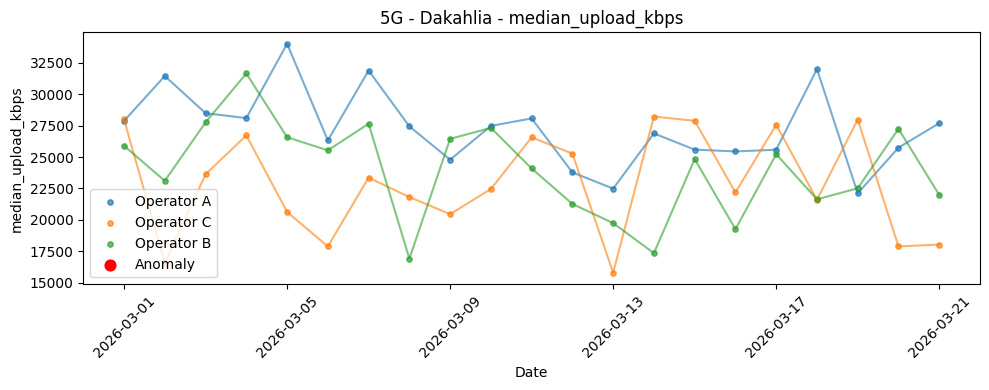

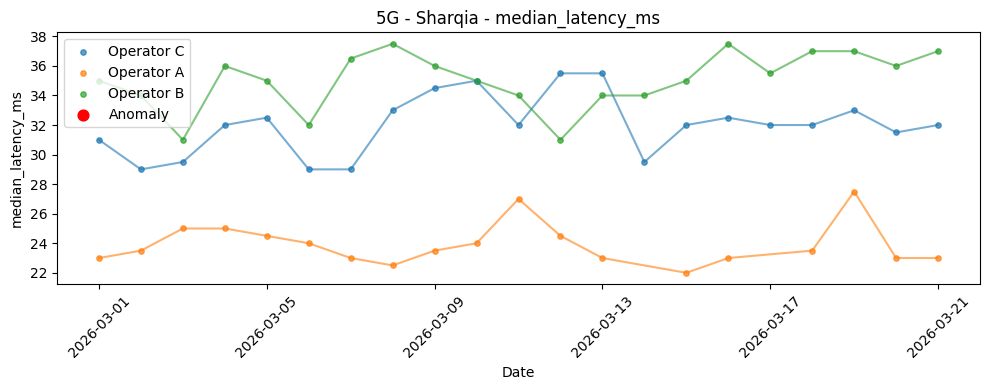

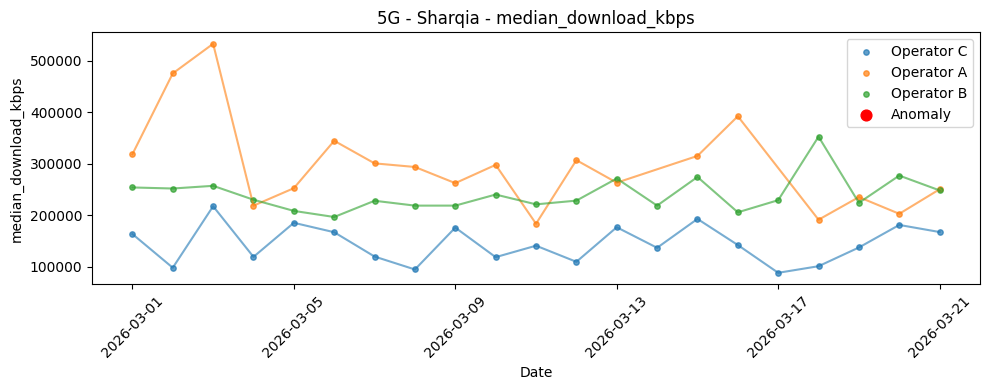

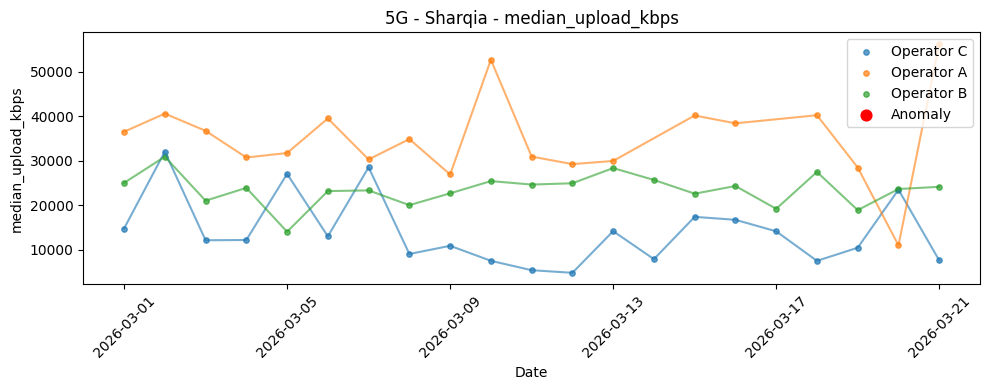

In [41]:
technologies = ['LTE', '5G']
regions = df_model['region'].value_counts().head(5).index

metrics = [
    'median_latency_ms',
    'median_download_kbps',
    'median_upload_kbps'
]

for tech in technologies:
    for region in regions:
        for metric in metrics:
            plot_region_tech(df_model, tech, region, metric)